<a href="https://colab.research.google.com/github/jay-nakrani/oil-price-prediction/blob/main/oil_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Assignment - Oil Price Forecasting

This notebook works through the oil price assignment. I'll be fitting an ARIMA model to the daily oil price data from 2024-2026, checking for stationarity, finding the best model parameters and then forecasting 24 months ahead. In part 2 I use Prophet as an alternative.

Dataset: oil_prices_2426.csv

# Part 1 - ARIMA model

In [1]:
# To import all the important libraries.
import numpy as np
import pandas as pd
from pandas import read_csv
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from itertools import product

plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['figure.dpi'] = 120

In [2]:
# To access the google drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1 - Load the data

Reading in the csv, renaming the columns and parsing the dates.
I also sort by date just to make sure everything is in order.

In [3]:
# To load the data from drive.
df = read_csv('/content/drive/MyDrive/oil_prices_2426.csv', header=0)
df.columns = ['date', 'price']

# To convert the date column to datetime so it can be used in time series analysis.
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# To sort the data by date from oldest to newest.
df = df.sort_values('date').reset_index(drop=True)

print(df.shape)

# To check if the dataset has any missing values.
print('any missing?', df.isnull().sum().sum())
df.head(10)

(500, 2)
any missing? 0


,date,price
0,2024-09-21,32.10
1,2024-09-22,32.25
2,2024-09-23,31.07
3,2024-09-24,31.50
4,2024-09-25,32.21
5,2024-09-26,33.38
6,2024-09-27,34.08
7,2024-09-28,34.43
8,2024-09-29,35.83
9,2024-09-30,36.33


## Step 2 - Exploratory Data Analysis

First thing I want to do is just look at the raw data and get a feel for what we're dealing with.

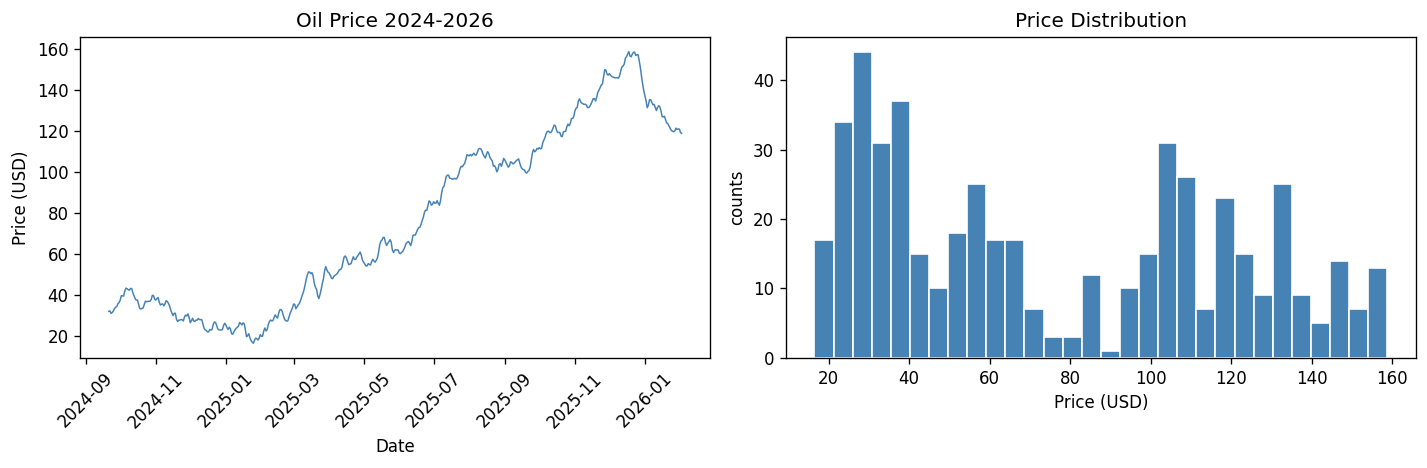

count    500.00
mean      75.87
std       42.91
min       16.48
25%       35.37
50%       64.29
75%      111.57
max      158.78
Name: price, dtype: float64


In [14]:
# To create two plots: one for the time series and one for the price distribution.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df['date'], df['price'], color='steelblue', linewidth=0.9)
axes[0].set_title('Oil Price 2024-2026')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)')

plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# To show how oil prices are distributed.
axes[1].hist(df['price'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Price Distribution')
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('counts')


plt.tight_layout()

plt.show()

# To print summary statistics of oil prices.
print(df['price'].describe().round(2))



There's a pretty clear upward trend - prices go from around 30 USD at the start up to about 160 USD by early 2026. That's a big move. The histogram is roughly bell shaped but it's spread quite wide because of the trend. This already tells me that the series is probably non-stationary, which I'll check properly with the ADF test below.

No obvious outliers or weird gaps in the data which is good.

## Step 3 - ACF and PACF

Before doing the formal test I want to look at the autocorrelation function.
If the ACF decays really slowly it's a sign of non-stationarity / unit root.

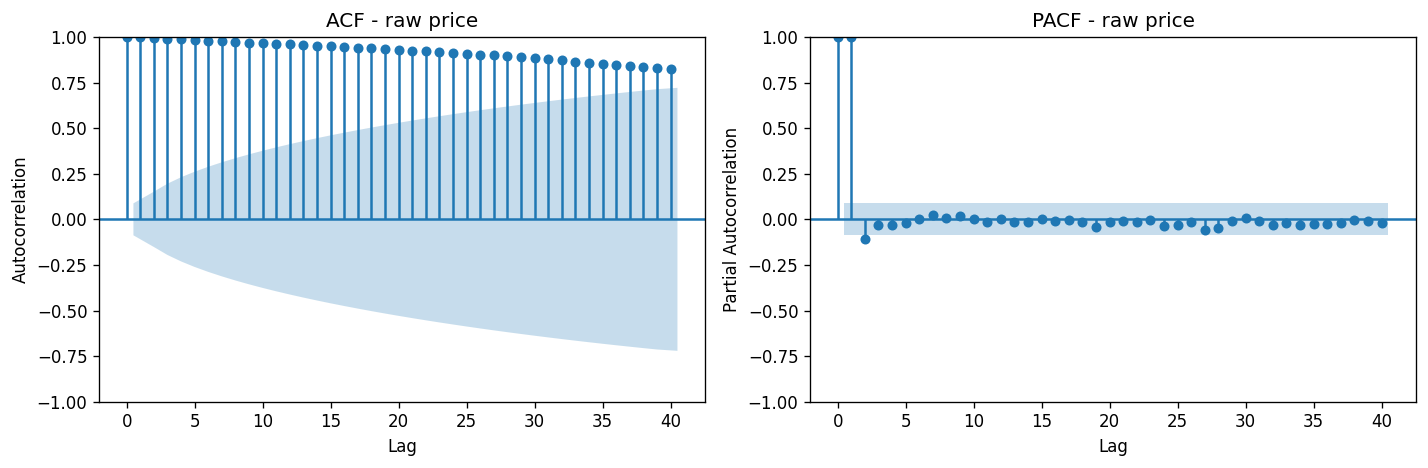

In [12]:
# To check autocorrelation patterns which help choose ARIMA parameters.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(df['price'], lags=40, ax=axes[0])
axes[0].set_title('ACF - raw price')
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(df['price'], lags=40, ax=axes[1])
axes[1].set_title('PACF - raw price')
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Partial Autocorrelation")

plt.tight_layout()

plt.show()

As expected the ACF is decaying very slowly - still significant at lag 40.
This is the classic pattern for a non-stationary series. The PACF drops off
quite sharply after lag 1 which hints at an AR(1) type structure underneath.

Need to difference the data to make it stationary before fitting anything.

## Step 4 - ADF test for stationarity

Using the Augmented Dickey-Fuller test to formally check for a unit root.

In [11]:
# To run the Augmented Dickey-Fuller test to check stationarity.
def adf_test(ts, label=''):
    result = adfuller(ts.dropna())
    print(f'ADF Test: {label}')
    print(f'  Statistic : {result[0]:.4f}')
    print(f'  p-value   : {result[1]:.4f}')

    # To check if the series is stationary based on the p-value.
    if result[1] <= 0.05:
        print('  --> stationary')
    else:
        print('  --> non-stationary')
    print()

adf_test(df['price'], label='raw data')
adf_test(df['price'].diff(), label='1st difference')
adf_test(df['price'].diff().diff(), label='2nd difference')

ADF Test: raw data
  Statistic : -0.5462
  p-value   : 0.8827
  --> non-stationary

ADF Test: 1st difference
  Statistic : -4.5415
  p-value   : 0.0002
  --> stationary

ADF Test: 2nd difference
  Statistic : -9.0042
  p-value   : 0.0000
  --> stationary



### From the results we can say that

The raw data is non-stationary as expected (p-value well above 0.05).
After taking the first difference the p-value goes below 0.05 so the differenced series is stationary - this means d=1 is sufficient. The grid search may still select d=2 if it gives a lower AIC, but d=1 achieves stationarity.

## Step 5 - Plotting the differenced series to confirm

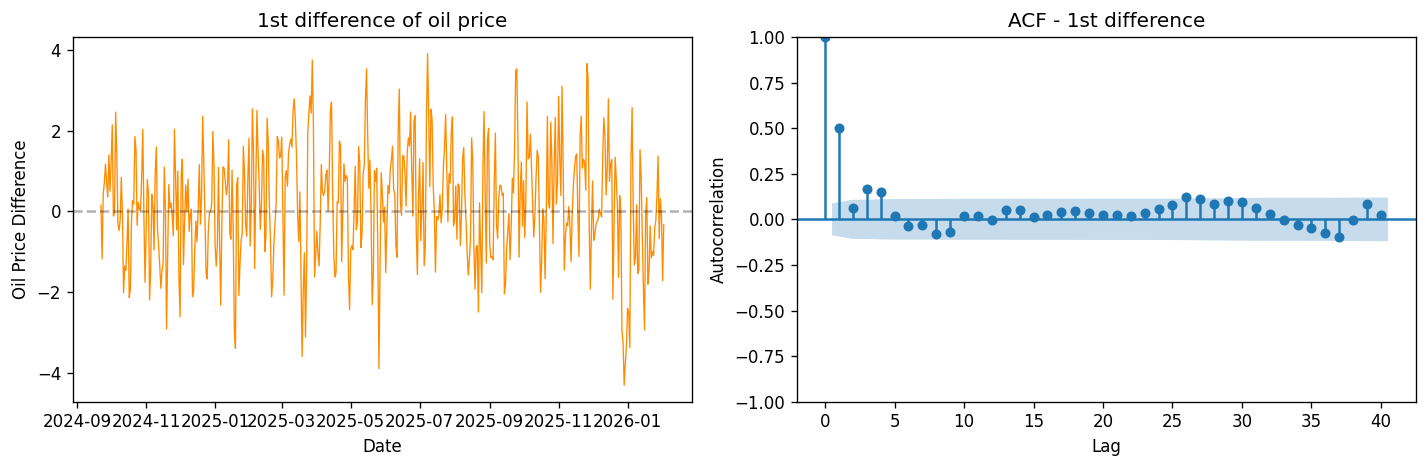

In [13]:
# To create the first difference of the price series to remove trend.
df['price_diff'] = df['price'].diff()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df['date'], df['price_diff'], color='darkorange', linewidth=0.8)
axes[0].axhline(0, color='k', linestyle='--', alpha=0.3)
axes[0].set_title('1st difference of oil price')
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Oil Price Difference")

# To check autocorrelation after differencing.
plot_acf(df['price_diff'].dropna(), lags=40, ax=axes[1])
axes[1].set_title('ACF - 1st difference')
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelation")

plt.tight_layout()

plt.show()

Much better, the differenced series is bouncing around zero with no trend,
and the ACF drops off quickly. Happy to proceed. The grid search below will
determine the optimal d value alongside p and q.

## Step 6 - Train/test split

Before fitting any model, I split the data into training and test sets.
The last 90 days are held out as the test set. The ARIMA model will only
be trained on the training data - the test set is kept completely unseen
until the evaluation step. This way we can analyse how the
model generalises to new data.

The same 90-day split is used for Prophet in Part 2, making the comparison fair.

In [15]:
# To split the data so the last 90 days are used for out-of-sample testing.
split_date = df['date'].max() - pd.Timedelta(days=90)

train_df = df[df['date'] <= split_date].copy()
test_df  = df[df['date'] >  split_date].copy()

print('Train:', len(train_df), 'rows')
print('Test: ', len(test_df),  'rows')
print('Split date:', split_date.date())

Train: 410 rows
Test:  90 rows
Split date: 2025-11-04


## Step 7 - Grid search to find the best p, d, q

Rather than just guessing, I'm going to loop over all combinations of
p = 0 to 8, d = 0 to 2, q = 0 to 8 and record the AIC for each one.
The model with the lowest AIC is the best fit - AIC penalises complexity
so it's not just picking the most overfit model.

**Important:** The grid search is run on the training data only. Using
the full dataset here would leak future information into the model selection step.

In [16]:
# To try many ARIMA parameter combinations and choose the best using AIC.
def optimize_ARIMA(ts, order_list):
    results = []
    for order in order_list:
        try:
            model = ARIMA(ts, order=order).fit()
            results.append([order, model.aic])
        except Exception:
            continue
    result_df = pd.DataFrame(results, columns=['order', 'AIC'])
    return result_df.sort_values('AIC').reset_index(drop=True)

p_range = range(0, 9)
d_range = range(0, 3)
q_range = range(0, 9)

# To create all possible ARIMA parameter combinations.
order_list = list(product(p_range, d_range, q_range))

print(f'Trying {len(order_list)} combinations on training data...')

Trying 243 combinations on training data...


In [17]:
# To run the grid search on training data only.
result_df = optimize_ARIMA(train_df['price'], order_list)

# To show the best ARIMA models with the lowest AIC.
result_df.head(10)

,order,AIC
0,"(0, 2, 6)",1157.218919
1,"(2, 2, 4)",1157.543741
2,"(0, 2, 5)",1157.630918
3,"(4, 2, 2)",1157.760438
4,"(3, 2, 2)",1157.832121
5,"(1, 2, 7)",1157.926147
6,"(8, 2, 2)",1157.962667
7,"(0, 2, 2)",1158.148900
8,"(6, 2, 2)",1158.313049
9,"(0, 1, 5)",1158.325034


The table is ordered lowest AIC first so the best model is at the top.
I'll use that order going forward.

## Step 8 - Fit best ARIMA model on training data

Now I fit the best-order model on the training data only.
This is the model that will be used for diagnostics, test set evaluation,
and the final 24-month forecast.

In [18]:
# To get the best ARIMA order from the grid search results.
best_order = result_df.iloc[0]['order']
print('Best order:', best_order)

# To fit the ARIMA model using training data only.
best_model     = ARIMA(train_df['price'], order=best_order)
best_model_fit = best_model.fit()

print(best_model_fit.summary())

Best order: (0, 2, 6)
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  410
Model:                 ARIMA(0, 2, 6)   Log Likelihood                -571.609
Date:                Thu, 12 Mar 2026   AIC                           1157.219
Time:                        09:55:45   BIC                           1185.298
Sample:                             0   HQIC                          1168.330
                                - 410                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0345      0.051     -0.673      0.501      -0.135       0.066
ma.L2         -0.9816      0.052    -18.813      0.000      -1.084      -0.879
ma.L3          0.1182      0.0

## Step 9 - In-sample fit metrics

Checking how well the model fits the training data it was trained on.
These are in-sample metrics - useful as a sanity check but should not
be used to compare against other models evaluated out-of-sample.

In [25]:
# To calculate in-sample error metrics on the training data.
rmse_is = np.sqrt(mean_squared_error(train_df['price'].iloc[1:], training_predictions.iloc[1:]))
mae_is  = np.mean(np.abs(residuals.dropna()))
mape_is = np.mean(np.abs(residuals.dropna() / train_df['price'].iloc[1:])) * 100

print(f'In-sample metrics (training data only)')
print(f'  RMSE : {rmse_is:.3f}')
print(f'  MAE  : {mae_is:.3f}')
print(f'  MAPE : {mape_is:.2f}%')

In-sample metrics (training data only)
  RMSE : 1.257
  MAE  : 0.903
  MAPE : 1.86%


MAPE is probably the most intuitive here - it tells you the average percentage
error. RMSE squares the errors first so it punishes big mistakes more heavily.
In-sample MAPE will be lower than out-of-sample MAPE because the model was
fitted on this exact data.

## Step 10 - In-sample model fit plot

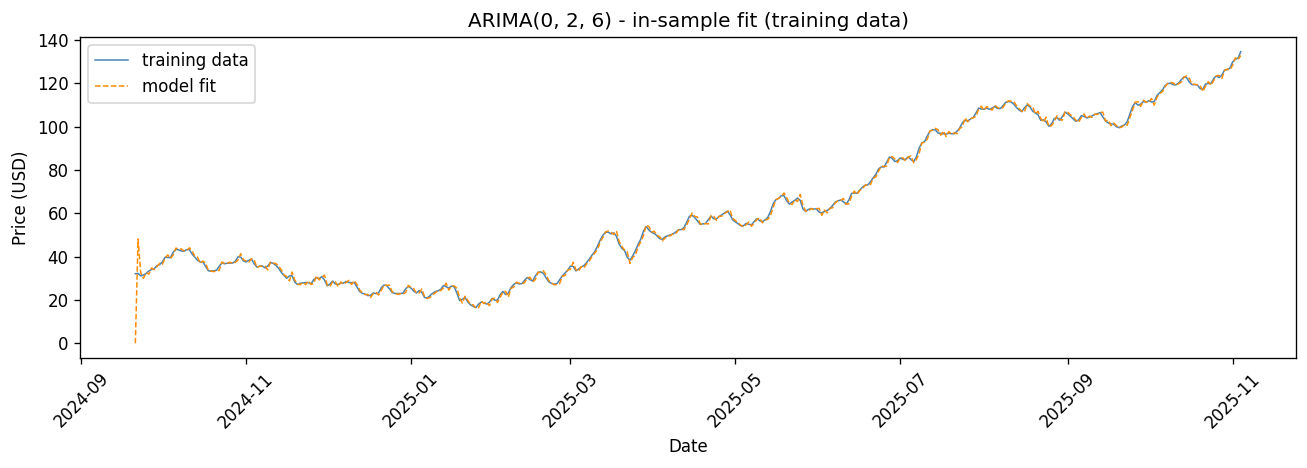

In [26]:
# To plot how well the ARIMA model fits the training data.
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(train_df['date'], train_df['price'],     label='training data', color='steelblue',  linewidth=0.9)
ax.plot(train_df['date'], training_predictions,  label='model fit',     color='darkorange', linewidth=0.9, linestyle='--')

ax.set_title(f'ARIMA{best_order} - in-sample fit (training data)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Step 11 - Model diagnostics

Checking the residuals from the training fit, I want them to look like white noise with a roughly normal distribution. If there's still structure left in the residuals it means the model hasn't captured everything.

This is done before looking at any test set results - diagnostics tell us whether the model is well specified on the data it was trained on.

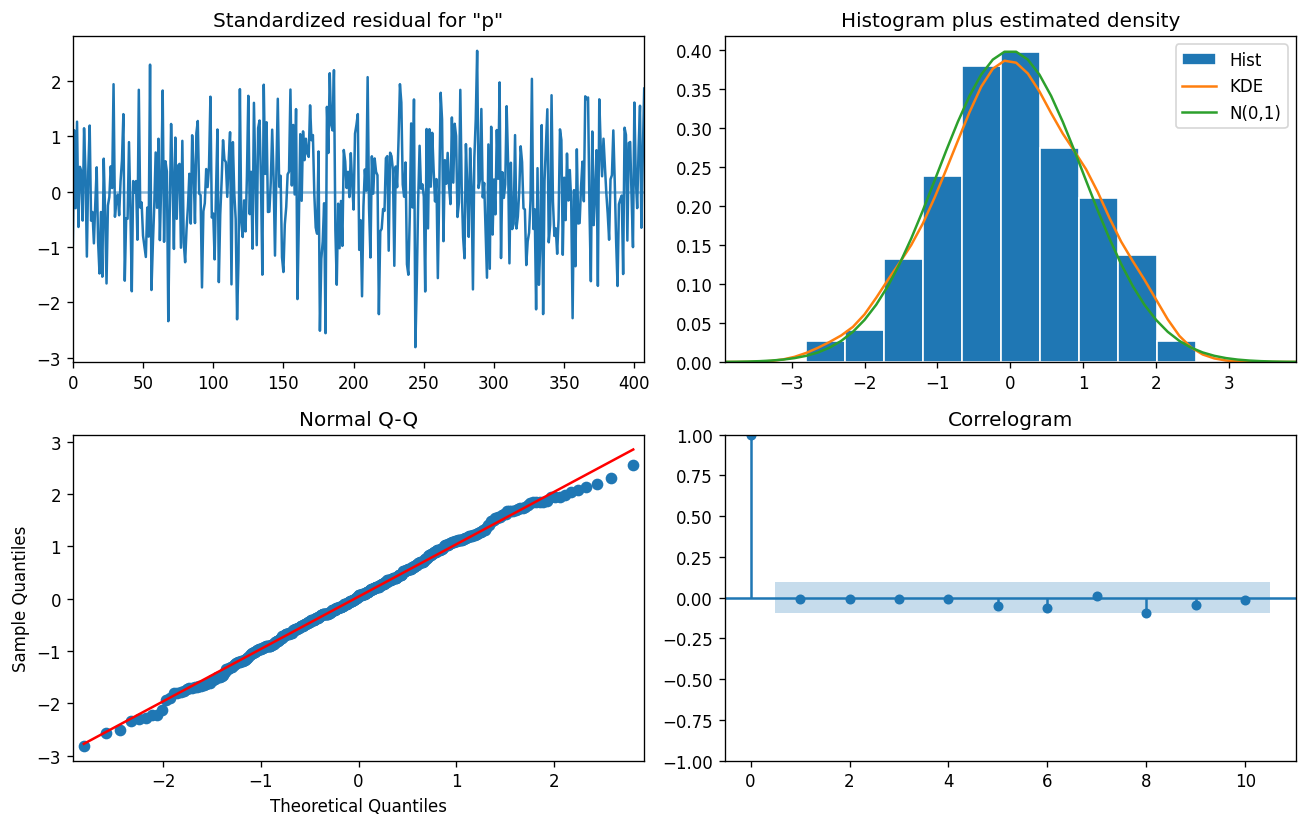

In [20]:
# To show diagnostic plots to check if model assumptions look reasonable.
best_model_fit.plot_diagnostics(figsize=(11, 7))
plt.tight_layout()

plt.show()

## Step 12 - Residuals - closer look

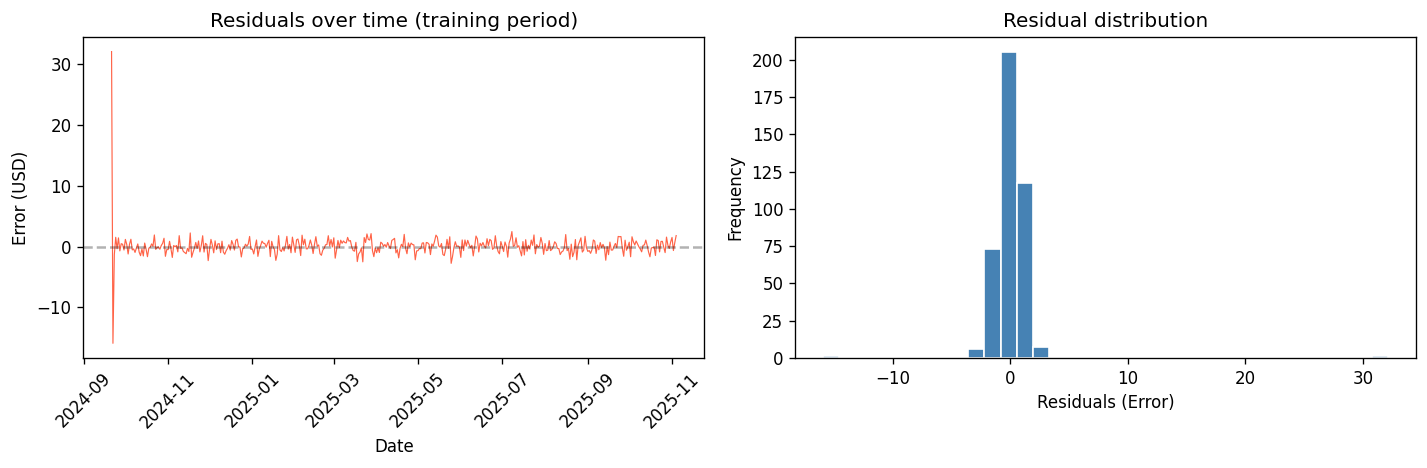

In [23]:
# To calculate residuals (difference between actual values and model predictions).
training_predictions = best_model_fit.fittedvalues
residuals = train_df['price'] - training_predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_df['date'], residuals, color='tomato', linewidth=0.7)
axes[0].axhline(0, color='k', linestyle='--', alpha=0.3)
axes[0].set_title('Residuals over time (training period)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Error (USD)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# To check how residuals are distributed.
axes[1].hist(residuals.dropna(), bins=35, color='steelblue', edgecolor='white')
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Residuals (Error)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()

plt.show()

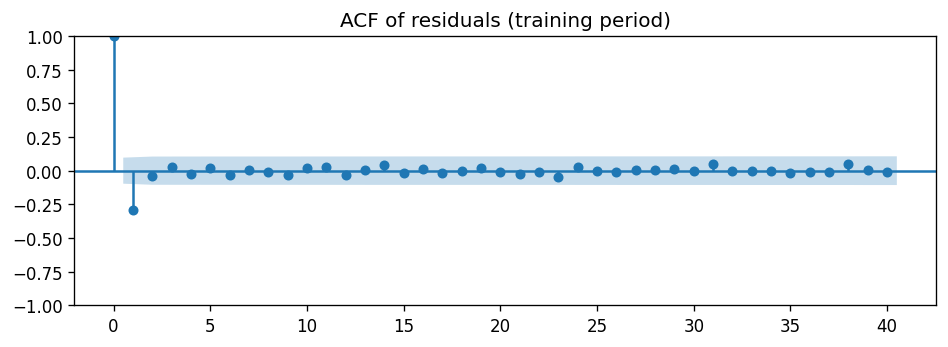

In [24]:
# To check if residuals still have autocorrelation.
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(residuals.dropna(), lags=40, ax=ax)
ax.set_title('ACF of residuals (training period)')
plt.tight_layout()

plt.show()

The residuals look reasonably well behaved - they're centred around zero
and the distribution is roughly symmetric. The ACF of residuals is mostly
within the bands which suggests the model has captured most of the structure.

There might be a small amount of remaining autocorrelation but it's not drastic.

## Step 13 - Out-of-sample test set predictions

Now I forecast the 90-day test period using the model trained on training data. These are genuinely out-of-sample predictions, the model has never seen the test data.

In [27]:
# To forecast the next 90 days and compare with the test dataset.
arima_test_fc   = best_model_fit.get_forecast(steps=len(test_df))
arima_test_mean = arima_test_fc.predicted_mean
arima_test_ci   = arima_test_fc.conf_int(alpha=0.05)

# To align index with test dates.
arima_test_mean.index = test_df['date'].values
arima_test_ci.index   = test_df['date'].values

# To calculate out-of-sample metrics using unseen test data.
rmse_oos = np.sqrt(mean_squared_error(test_df['price'], arima_test_mean))
mae_oos  = np.mean(np.abs(test_df['price'].values - arima_test_mean.values))
mape_oos = np.mean(np.abs((test_df['price'].values - arima_test_mean.values) / test_df['price'].values)) * 100

print(f'ARIMA{best_order} - out-of-sample metrics (90-day test set)')
print(f'  RMSE : {rmse_oos:.3f}')
print(f'  MAE  : {mae_oos:.3f}')
print(f'  MAPE : {mape_oos:.2f}%')

ARIMA(0, 2, 6) - out-of-sample metrics (90-day test set)
  RMSE : 24.827
  MAE  : 17.151
  MAPE : 13.43%


## Step 14 - Test set plot

Plotting the ARIMA predictions on the held-out test period alongside the actual prices.

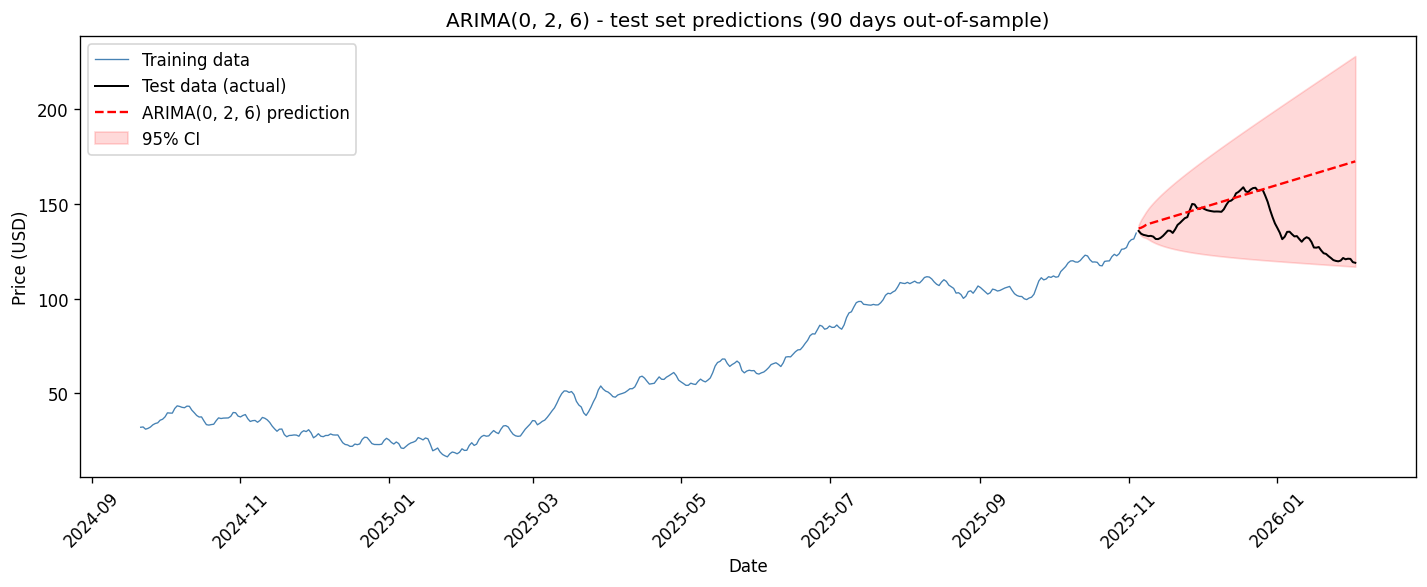

In [29]:
# To visualise ARIMA predictions on test dataset.
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(train_df['date'], train_df['price'],
        color='steelblue', lw=0.8, label='Training data')
ax.plot(test_df['date'],  test_df['price'],
        color='black', lw=1.2, label='Test data (actual)')
ax.plot(arima_test_mean.index, arima_test_mean,
        color='red', lw=1.4, linestyle='--', label=f'ARIMA{best_order} prediction')
ax.fill_between(arima_test_ci.index,
                arima_test_ci.iloc[:, 0], arima_test_ci.iloc[:, 1],
                color='red', alpha=0.15, label='95% CI')

ax.set_title(f'ARIMA{best_order} - test set predictions (90 days out-of-sample)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Step 15 - Refit on full data and forecast 24 months ahead

Now that the model has been validated, I refit it on the entire dataset before making the final 24-month forecast. This is the standard practice to use all available data to get the best possible parameter estimates for the long-run forecast.

The model order (p, d, q) is fixed from the grid search. Only the coefficients are reestimated using the full data.

In [30]:
# To refit the ARIMA model on the full dataset before making the final forecast.
full_model     = ARIMA(df['price'], order=best_order)
full_model_fit = full_model.fit()

print(f'ARIMA{best_order} refitted on full dataset ({len(df)} observations)')

ARIMA(0, 2, 6) refitted on full dataset (500 observations)


In [31]:
# To forecast about 24 months into the future.
n_forecast = 730

forecast_obj  = full_model_fit.get_forecast(steps=n_forecast)
forecast_mean = forecast_obj.predicted_mean
conf_int      = forecast_obj.conf_int(alpha=0.05)

# To make a date index for the forecast.
last_date      = df['date'].iloc[-1]

# To create future dates for the forecast period.
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_forecast, freq='D')

conf_int.index      = forecast_dates
forecast_mean.index = forecast_dates

pd.concat([forecast_mean.rename('forecast'), conf_int], axis=1).head()

,forecast,lower price,upper price
2026-02-03,119.177428,117.220074,121.134782
2026-02-04,119.027520,114.722524,123.332517
2026-02-05,118.941658,113.177809,124.705507
2026-02-06,119.090632,112.016247,126.165016
2026-02-07,119.278616,110.851211,127.706022


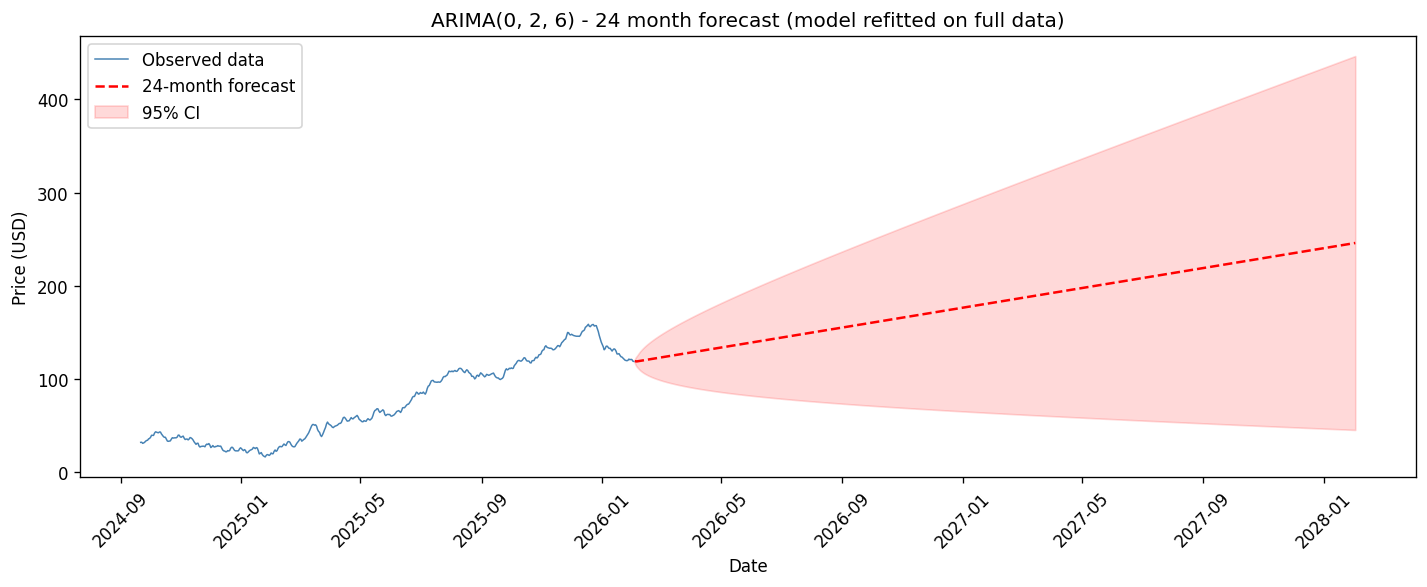

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['date'], df['price'],  color='steelblue',  linewidth=0.9, label='Observed data')
ax.plot(forecast_dates, forecast_mean, color='red',   linewidth=1.5, linestyle='--', label='24-month forecast')
ax.fill_between(forecast_dates,
                conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                color='red', alpha=0.15, label='95% CI')

ax.set_title(f'ARIMA{best_order} - 24 month forecast (model refitted on full data)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

The confidence interval fans out quite a lot over 24 months which makes sense the further ahead you forecast, the more uncertain things get. ARIMA accumulates uncertainty at each step so for long horizons the bands get very wide.

The model is basically extrapolating the trend it has learned from the data.
Whether that's actually what will happen depends on lots of things outside
the model (geopolitics, supply shocks etc) that we can't capture here.

---
# Part 2 - Prophet model

For the alternative model I decided to use Prophet, which is a forecasting library originally developed by Meta. I chose it because:

1. It's designed specifically for time series with trends and seasonality which fits this data pretty well
2. It doesn't need the series to be stationary so it removes that preprocessing step
3. It decomposes the series into trend + seasonality components which is more interpretable than just getting one combined output like ARIMA gives you

The main reference for Prophet is Taylor & Letham (2018) - *Forecasting at scale*,The American Statistician, 72(1). They describe how it decomposes the series as:

$y(t) = g(t) + s(t) + h(t) + \epsilon_t$

where $g(t)$ is the trend, $s(t)$ is seasonality modelled using Fourier series, $h(t)$ captures holiday effects and $\epsilon_t$ is the noise term.

In [34]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error

## Preparing data for Prophet

Prophet needs the dataframe to have two specific columns - 'ds' for the dates
and 'y' for the values. Just renaming here.

In [35]:
# To prepare the data in Prophet format (ds = date, y = value).
prophet_df = df[['date', 'price']].rename(columns={'date': 'ds', 'price': 'y'})
prophet_df = df[['date', 'price']].rename(columns={'date': 'ds', 'price': 'y'})
prophet_df.head()

,ds,y
0,2024-09-21,32.10
1,2024-09-22,32.25
2,2024-09-23,31.07
3,2024-09-24,31.50
4,2024-09-25,32.21


## Train/test split

Using the same 90-day holdout as ARIMA. This means both models are
evaluated on exactly the same test period, making the comparison fair.

Prophet is trained only on the training portion here.

In [36]:
# To split Prophet data into training and test sets.
split_date_p = prophet_df['ds'].max() - pd.Timedelta(days=90)

train_p = prophet_df[prophet_df['ds'] <= split_date_p].copy()
test_p  = prophet_df[prophet_df['ds'] >  split_date_p].copy()

print('Train:', len(train_p), 'rows')
print('Test: ', len(test_p),  'rows')

Train: 410 rows
Test:  90 rows


## Fitting Prophet

The two main parameters I'm tuning here are:
- changepoint_prior_scale - controls how much the trend is allowed to change. Higher = more flexible trend but risks overfitting. I'm keeping this at 0.05
  (the default) which gives a reasonably smooth trend.
- seasonality_prior_scale - controls the strength of seasonal components.
  I've set this to 10 which lets the seasonality fit fairly closely to the data.

In [37]:
# To create and train the Prophet forecasting model.
prophet_model = Prophet(yearly_seasonality  = True,
                        weekly_seasonality  = True,
                        daily_seasonality   = False,
                        changepoint_prior_scale  = 0.05,
                        seasonality_prior_scale  = 10.0)

prophet_model.fit(train_p)

## Predictions on the test set

In [38]:
# To forecast the next 90 days using Prophet.
future_test      = prophet_model.make_future_dataframe(periods=90)
forecast_prophet = prophet_model.predict(future_test)

# To pull out just the test period.
forecast_test = forecast_prophet[forecast_prophet['ds'] > split_date_p][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']].set_index('ds')

actual_test = test_p.set_index('ds')['y']

# To calculate Prophet forecasting errors on the test data.
rmse_p = np.sqrt(mean_squared_error(actual_test, forecast_test['yhat']))
mae_p  = np.mean(np.abs(actual_test - forecast_test['yhat']))
mape_p = np.mean(np.abs((actual_test - forecast_test['yhat']) / actual_test)) * 100

print(f'Prophet - out-of-sample metrics (90-day test set)')
print(f'  RMSE : {rmse_p:.3f}')
print(f'  MAE  : {mae_p:.3f}')
print(f'  MAPE : {mape_p:.2f}%')

Prophet - out-of-sample metrics (90-day test set)
  RMSE : 16.679
  MAE  : 14.711
  MAPE : 10.56%


## Component decomposition

One of the things I like about Prophet is you can actually see the separate
trend and seasonality components. This gives a lot more insight into what's
driving the forecast compared to ARIMA.

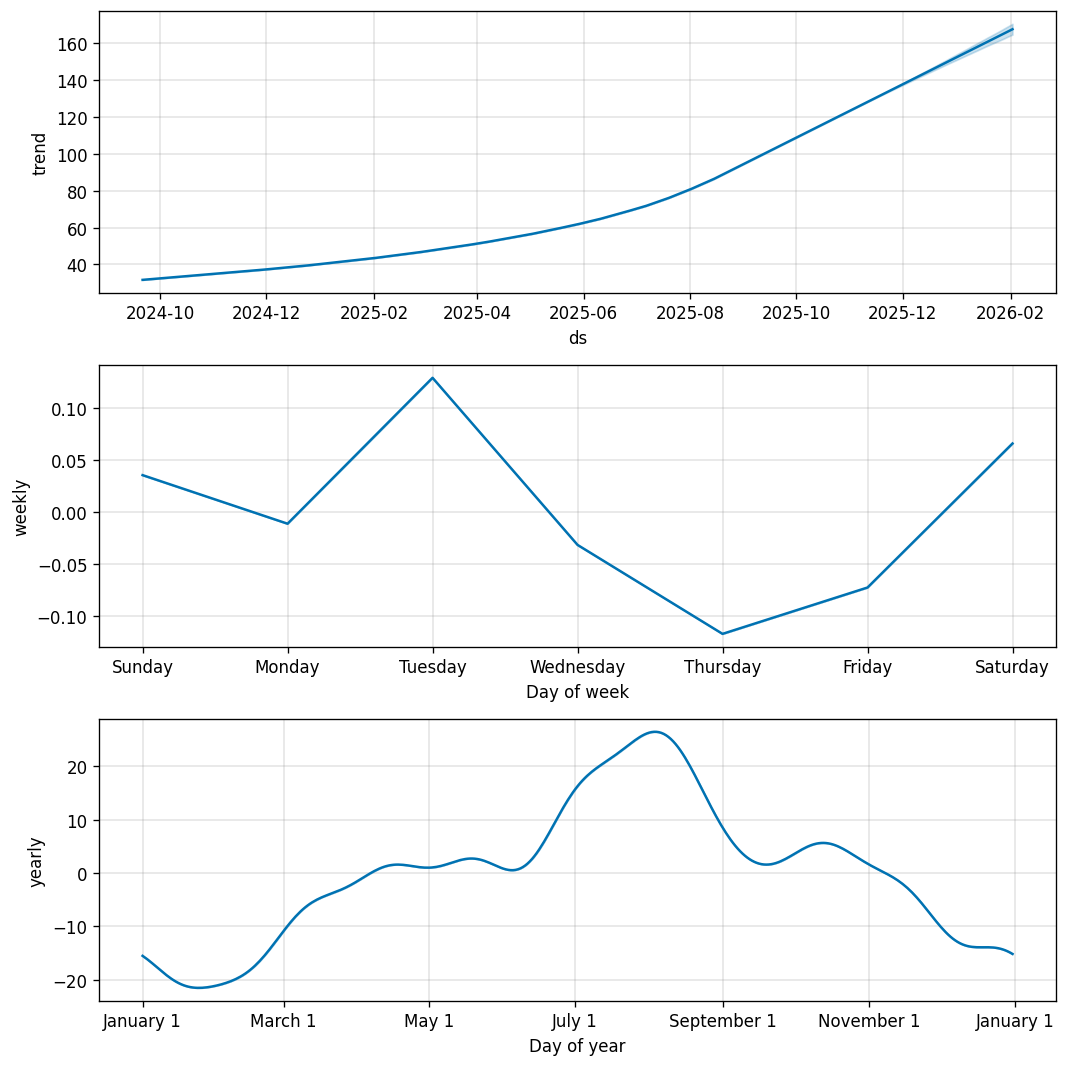

In [39]:
fig = prophet_model.plot_components(forecast_prophet)
plt.tight_layout()
plt.show()

The trend component captures the long-run upward movement in prices.
The weekly seasonality shows whether prices tend to be higher/lower on
certain days of the week, and the yearly component picks up any annual cycles.

## Test period

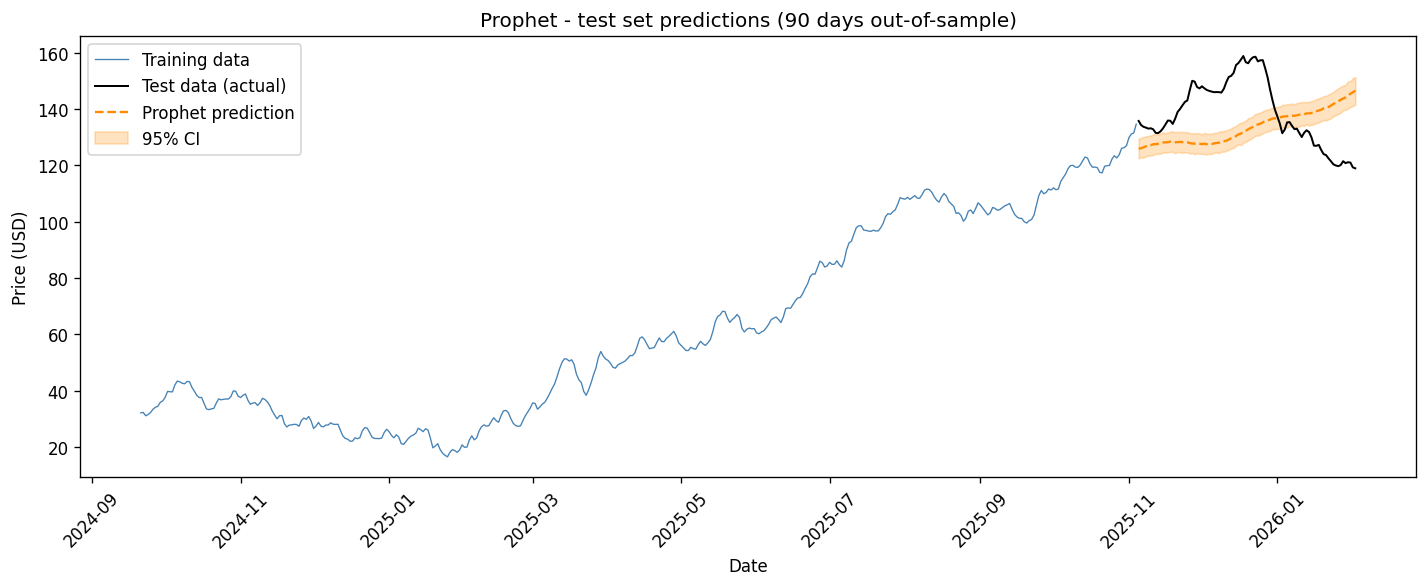

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(train_p['ds'], train_p['y'], color='steelblue', lw=0.8, label='Training data')
ax.plot(test_p['ds'], test_p['y'], color='black', lw=1.2, label='Test data (actual)')
ax.plot(forecast_test.index, forecast_test['yhat'],
        color='darkorange', lw=1.4, linestyle='--', label='Prophet prediction')
ax.fill_between(forecast_test.index,
                forecast_test['yhat_lower'], forecast_test['yhat_upper'],
                color='darkorange', alpha=0.25, label='95% CI')

ax.set_title('Prophet - test set predictions (90 days out-of-sample)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Retrain on full data and forecast 24 months

Now that Prophet has been validated on the test set, I retrain on the entire
dataset before making the final 24-month forecast. Same logic as with ARIMA,
use all available data to get the best coefficient estimates for the long-run forecast.

In [41]:
# To refit Prophet on the full dataset before making the long-term forecast.
prophet_full = Prophet(yearly_seasonality = True,
                      weekly_seasonality = True,
                      daily_seasonality  = False,
                      changepoint_prior_scale = 0.05,
                      seasonality_prior_scale = 10.0)
prophet_full.fit(prophet_df)

future_730   = prophet_full.make_future_dataframe(periods=730)
forecast_730 = prophet_full.predict(future_730)

Forecast done


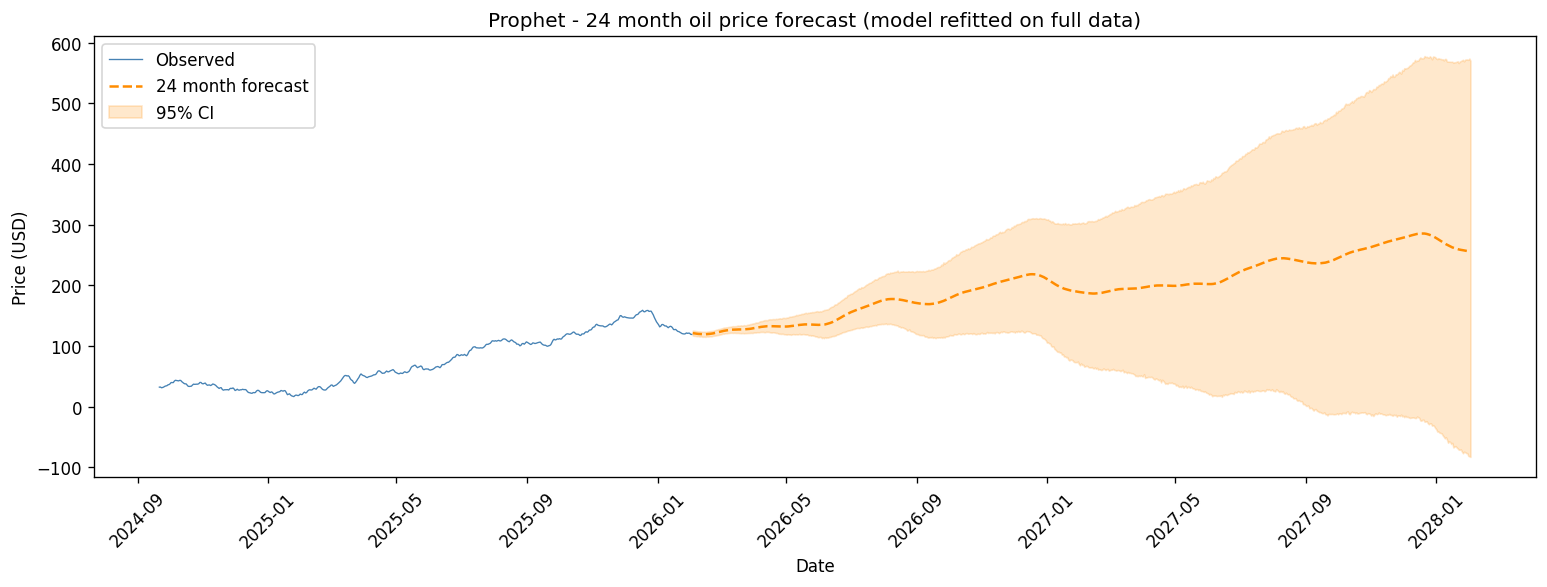

In [42]:
forecast_future = forecast_730[forecast_730['ds'] > prophet_df['ds'].max()]

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(prophet_df['ds'], prophet_df['y'], color='steelblue', lw=0.8, label='Observed')
ax.plot(forecast_future['ds'], forecast_future['yhat'],
        color='darkorange', lw=1.5, linestyle='--', label='24 month forecast')
ax.fill_between(forecast_future['ds'],
                forecast_future['yhat_lower'], forecast_future['yhat_upper'],
                color='darkorange', alpha=0.2, label='95% CI')

ax.set_title('Prophet - 24 month oil price forecast (model refitted on full data)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ARIMA vs Prophet - side by side comparison

Plotting both forecasts together to compare how they differ.

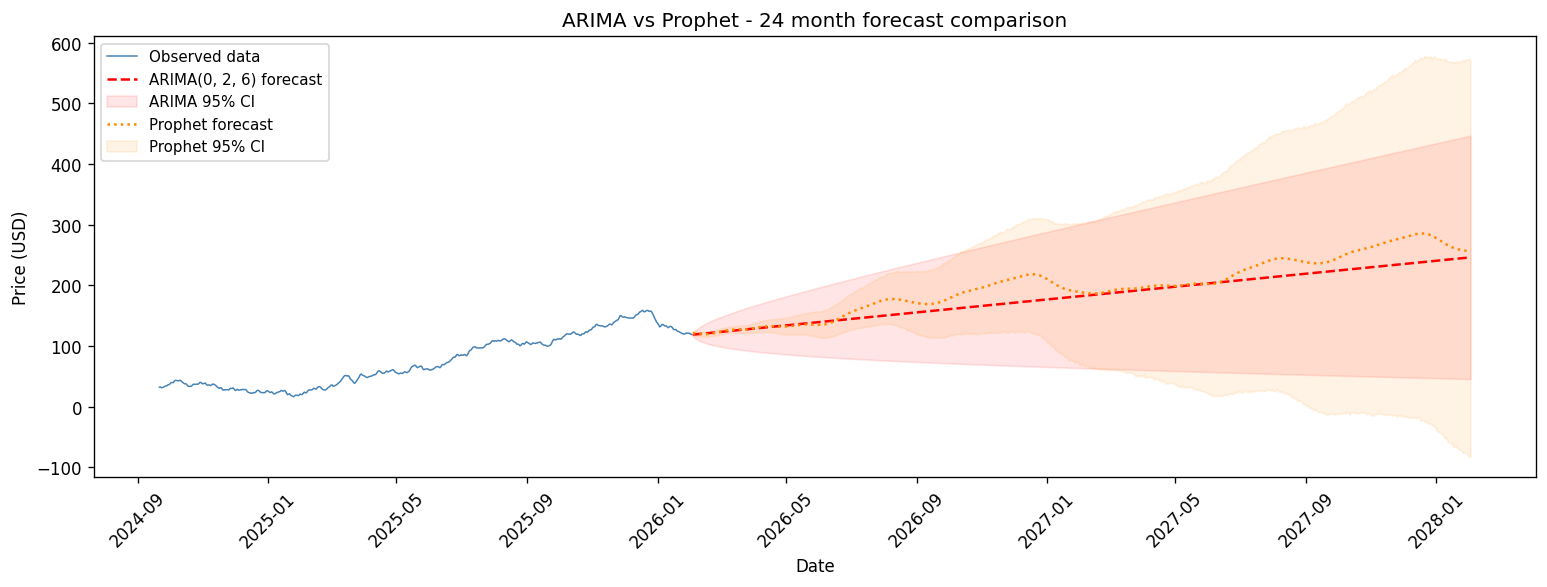

In [43]:
# To compare ARIMA and Prophet forecasts on the same graph.
fig, ax = plt.subplots(figsize=(13, 5))

# data
ax.plot(df['date'], df['price'], color='steelblue', lw=0.9, label='Observed data', zorder=3)

# arima
ax.plot(forecast_dates, forecast_mean,
        color='red', lw=1.5, linestyle='--', label=f'ARIMA{best_order} forecast')
ax.fill_between(forecast_dates,
                conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                color='red', alpha=0.1, label='ARIMA 95% CI')

# prophet
ax.plot(forecast_future['ds'], forecast_future['yhat'],
        color='darkorange', lw=1.5, linestyle=':', label='Prophet forecast')
ax.fill_between(forecast_future['ds'],
                forecast_future['yhat_lower'], forecast_future['yhat_upper'],
                color='darkorange', alpha=0.1, label='Prophet 95% CI')

ax.set_title('ARIMA vs Prophet - 24 month forecast comparison')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig22_raw.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary metrics - fair comparison

Both models are now evaluated on the **same 90-day holdout period**.
Neither model saw the test data during training or model selection,
so the metrics are directly comparable.

In [45]:
# To print the final comparison of both models using the same test set.
print('Model comparison - out-of-sample (same 90-day test set)')
print('=' * 55)
print(f'ARIMA{best_order}')
print(f'  RMSE : {rmse_oos:.3f}')
print(f'  MAE  : {mae_oos:.3f}')
print(f'  MAPE : {mape_oos:.2f}%')

print('\nProphet')
print(f'  RMSE : {rmse_p:.3f}')
print(f'  MAE  : {mae_p:.3f}')
print(f'  MAPE : {mape_p:.2f}%')

Model comparison - out-of-sample (same 90-day test set)
ARIMA(0, 2, 6)
  RMSE : 24.827
  MAE  : 17.151
  MAPE : 13.43%

Prophet
  RMSE : 16.679
  MAE  : 14.711
  MAPE : 10.56%
